# 1-hour sweep: LLM-LA (mine) vs BooM — head-to-head

Comprehensive comparison of the **seven 1-hour cells** (exps **115–121**), all running the
*same* 110-turn Claude/CodeFlowBench workload under identical harness code.

| exp | side | strategy | path |
|----|------|----------|------|
| 115 | **mine** | both + hard affinity | us + LLM-LA router (`pull`) |
| 116 | **mine** | affinity hard only | us + LLM-LA router (`pull`) |
| 117 | **mine** | affinity soft only | us + LLM-LA router (`pull`) |
| 118 | **mine** | prefix only | us + LLM-LA router (`pull`) |
| 119 | boom | round_robin | BooM direct |
| 120 | boom | key_affinity | BooM direct |
| 121 | boom | kvc_aware | BooM direct |

**Data-quality notes (why we compute from raw, not the summaries):**
- Per-turn Claude log is `claude_client_logs.json` for *mine* and `logs.json` for *boom* — same schema.
- `cache_read_input_tokens` / `cache_creation_input_tokens` are **0** (Anthropic caching is not reported through the local vLLM path) → not a usable KV signal here.
- `metrics_summary.json` and engine `prefix_cache_hit_rate` came back zero/empty → **ignored**; fleet stats are recomputed from `metrics.jsonl` per-pod samples.
- Router-level `kv_hit` exists only for *mine* (BooM direct has no router log). We surface it as mine-only routing detail.
- All 7 cells processed the **same 110 turns**, so per-turn latency is directly comparable; the wall-clock **makespan** to clear those 110 turns is itself a headline metric.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

EXPERIMENTS_ROOT = "/home/saeid/llm-la/src/client/experiments"

# exp -> (side, strategy). Order defines plot order.
REGISTRY = {
    115: ("mine", "both+hard"),
    116: ("mine", "aff-hard"),
    117: ("mine", "aff-soft"),
    118: ("mine", "prefix"),
    119: ("boom", "rr"),
    120: ("boom", "key_aff"),
    121: ("boom", "kvc"),
}
EXP_IDS = [e for e in REGISTRY if (Path(EXPERIMENTS_ROOT) / str(e)).is_dir()]

def side(e):   return REGISTRY[e][0]
def strat(e):  return REGISTRY[e][1]
def label(e):  return f"{e}:{side(e)}/{strat(e)}"
LABELS = {e: label(e) for e in EXP_IDS}

# blue family = mine, warm family = boom
_MINE = ["#1f4e8c", "#2b6cb0", "#4C78A8", "#7fa8d0"]
_BOOM = ["#B4413C", "#E45756", "#F58518"]
def color(e):
    if side(e) == "mine":
        return _MINE[[x for x in EXP_IDS if side(x) == "mine"].index(e) % len(_MINE)]
    return _BOOM[[x for x in EXP_IDS if side(x) == "boom"].index(e) % len(_BOOM)]
COLORS = {e: color(e) for e in EXP_IDS}

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 60)

def exp_dir(e): return Path(EXPERIMENTS_ROOT) / str(e)

def _read_json(p):
    p = Path(p)
    return json.load(p.open()) if p.is_file() else None

def _read_ndjson(p):
    p = Path(p); rows = []
    if not p.is_file():
        return rows
    for line in p.open("r", encoding="utf-8"):
        line = line.strip()
        if not line:
            continue
        try:
            rows.append(json.loads(line))
        except Exception:
            pass
    return rows

def turns_path(e):
    """Per-turn Claude log: mine -> claude_client_logs.json, boom -> logs.json."""
    p = exp_dir(e) / "claude_client_logs.json"
    return p if p.is_file() else (exp_dir(e) / "logs.json")

def bar_by_exp(values, title, ylabel, fmt="{:.1f}", figsize=(11, 4), rot=25):
    xs = [e for e in EXP_IDS if e in values and pd.notna(values[e])]
    fig, ax = plt.subplots(figsize=figsize)
    ax.bar(range(len(xs)), [values[e] for e in xs],
           color=[COLORS[e] for e in xs], edgecolor="black")
    ax.set_xticks(range(len(xs)))
    ax.set_xticklabels([LABELS[e] for e in xs], rotation=rot, ha="right", fontsize=8)
    ax.set_title(title); ax.set_ylabel(ylabel); ax.grid(axis="y", alpha=.3)
    for i, e in enumerate(xs):
        ax.text(i, values[e], fmt.format(values[e]), ha="center", va="bottom", fontsize=7)
    ax.legend(handles=[Patch(color="#4C78A8", label="mine (LLM-LA router)"),
                       Patch(color="#E45756", label="boom (direct)")], fontsize=8)
    plt.tight_layout(); plt.show()

print("cells found:", EXP_IDS)

cells found: [115, 116, 117, 118, 119, 120, 121]


## 1. Registry & workload
Deployed settings, turns processed, and wall-clock makespan per cell.

In [2]:
def load_meta(e):
    rs = _read_json(exp_dir(e) / "run_summary.json") or {}
    tp = turns_path(e)
    n_turns = sum(1 for _ in _read_ndjson(tp))
    return {
        "exp": e, "side": side(e), "strategy": strat(e), "label": LABELS[e],
        "turns": n_turns,
        "wall_s": rs.get("wall_time_s"),
        "load_s": rs.get("load_runner_duration_s"),
        "total_requests": rs.get("total_requests"),
        "turn_src": tp.name,
    }

REG = pd.DataFrame([load_meta(e) for e in EXP_IDS]).set_index("exp")
REG["wall_min"] = (REG["wall_s"] / 60).round(1)
REG["load_min"] = (REG["load_s"] / 60).round(1)
display(REG[["side", "strategy", "label", "turns", "load_min", "wall_min",
             "total_requests", "turn_src"]])

,side,strategy,label,turns,load_min,wall_min,total_requests,turn_src
exp,,,,,,,,
115,mine,both+hard,115:mine/both+hard,110,65.1,66.7,32,claude_client_logs.json
116,mine,aff-hard,116:mine/aff-hard,110,148.0,149.8,32,claude_client_logs.json
117,mine,aff-soft,117:mine/aff-soft,110,96.8,98.4,32,claude_client_logs.json
118,mine,prefix,118:mine/prefix,110,55.1,56.5,32,claude_client_logs.json
119,boom,rr,119:boom/rr,110,168.9,168.9,32,logs.json
120,boom,key_aff,120:boom/key_aff,110,124.2,124.2,32,logs.json
121,boom,kvc,121:boom/kvc,110,129.8,129.8,32,logs.json


## 2. Per-turn latency (headline)
End-to-end wall time per Claude turn (`end_to_end_s`) and server API time (`api_ms`).
All cells ran the same 110 turns, so these percentiles are directly comparable.

In [3]:
def load_turns(e):
    df = pd.DataFrame(_read_ndjson(turns_path(e)))
    if df.empty:
        return df
    for c in ["prompt_tokens", "completion_tokens", "end_to_end_s", "api_ms",
              "duration_ms", "cache_read_input_tokens", "cache_creation_input_tokens",
              "conversation_id", "user_id", "turn_idx", "num_turns"]:
        if c not in df.columns:
            df[c] = np.nan
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df["exp"] = e; df["side"] = side(e); df["strategy"] = strat(e); df["label"] = LABELS[e]
    df["api_s"] = df["api_ms"] / 1000.0
    df = df.sort_values(["user_id", "conversation_id", "turn_idx"])
    grp = df.groupby(["user_id", "conversation_id"])
    df["turn_type"] = np.where(df["turn_idx"].fillna(0) == 0, "first", "repeat")
    return df

TURNS = pd.concat([load_turns(e) for e in EXP_IDS], ignore_index=True)

def pctl_table(df, col):
    g = df.groupby("exp")[col]
    out = pd.DataFrame({
        "n": g.size(),
        "mean": g.mean(),
        "p50": g.quantile(.50),
        "p90": g.quantile(.90),
        "p95": g.quantile(.95),
        "p99": g.quantile(.99),
        "max": g.max(),
    })
    out.index = [LABELS[e] for e in out.index]
    return out

print("=== end_to_end_s (per turn) ===")
LAT = pctl_table(TURNS, "end_to_end_s")
display(LAT.round(2))
print("=== api_s (server time per turn) ===")
display(pctl_table(TURNS, "api_s").round(2))

=== end_to_end_s (per turn) ===


,n,mean,p50,p90,p95,p99,max
115:mine/both+hard,110,168.25,62.02,480.91,852.57,1328.14,1402.54
116:mine/aff-hard,110,212.56,69.19,438.05,882.72,2739.18,4395.24
117:mine/aff-soft,110,189.82,73.82,203.10,326.40,3515.49,5401.09
118:mine/prefix,110,135.80,74.13,221.57,268.65,913.92,2978.48
119:boom/rr,110,263.28,84.26,518.35,647.87,1527.73,7757.73
120:boom/key_aff,110,250.35,114.63,459.45,704.19,1814.78,6394.94
121:boom/kvc,110,242.23,94.64,517.23,990.32,1694.53,5076.27


=== api_s (server time per turn) ===


,n,mean,p50,p90,p95,p99,max
115:mine/both+hard,110,163.10,57.23,474.81,844.88,1281.18,1396.20
116:mine/aff-hard,110,206.80,64.23,432.99,876.51,2732.92,4385.64
117:mine/aff-soft,110,184.77,69.05,197.70,318.19,3508.44,5389.32
118:mine/prefix,110,131.19,69.34,216.36,263.77,906.43,2970.19
119:boom/rr,110,258.49,79.44,512.78,642.81,1521.62,7747.05
120:boom/key_aff,110,246.06,110.02,454.54,698.82,1809.10,6377.85
121:boom/kvc,110,233.95,92.81,515.89,896.74,1688.84,5059.76


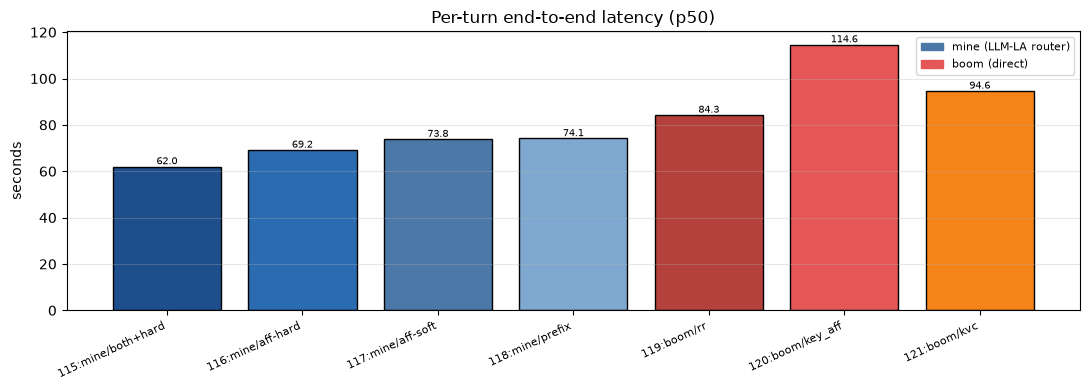

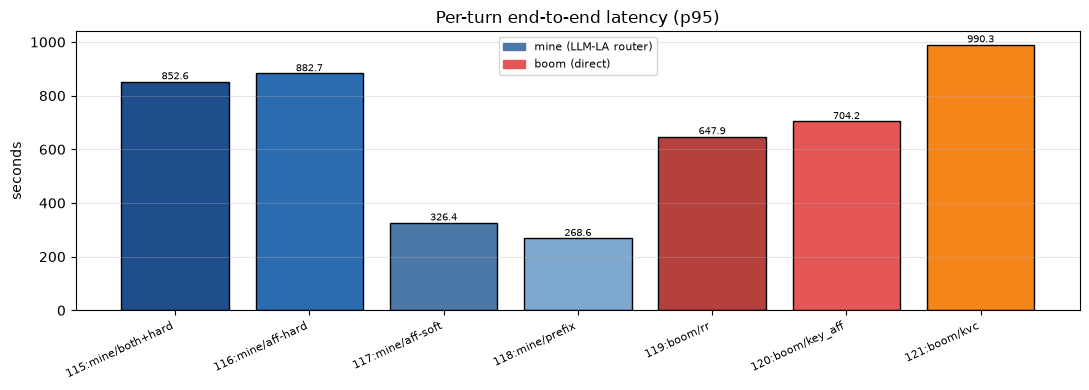

In [4]:
e2e_p50 = TURNS.groupby("exp")["end_to_end_s"].quantile(.50).to_dict()
e2e_p95 = TURNS.groupby("exp")["end_to_end_s"].quantile(.95).to_dict()
bar_by_exp(e2e_p50, "Per-turn end-to-end latency (p50)", "seconds", fmt="{:.1f}")
bar_by_exp(e2e_p95, "Per-turn end-to-end latency (p95)", "seconds", fmt="{:.1f}")

### 2b. Latency by turn index
Does latency improve on later turns of a conversation (context reuse paying off)?

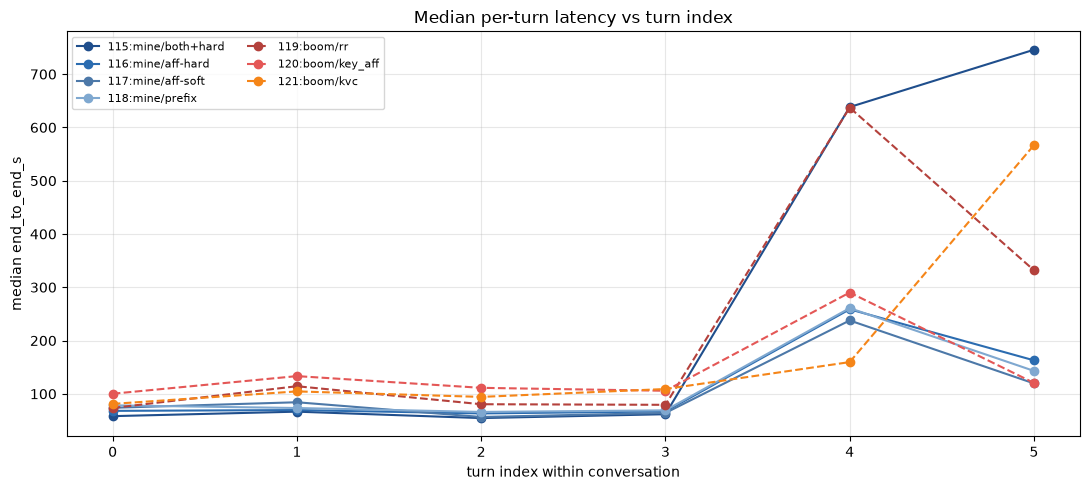

In [5]:
fig, ax = plt.subplots(figsize=(11, 5))
for e in EXP_IDS:
    d = TURNS[TURNS["exp"] == e]
    m = d.groupby("turn_idx")["end_to_end_s"].median()
    if m.empty:
        continue
    ax.plot(m.index, m.values, marker="o", color=COLORS[e], label=LABELS[e],
            ls="--" if side(e) == "boom" else "-")
ax.set_xlabel("turn index within conversation"); ax.set_ylabel("median end_to_end_s")
ax.set_title("Median per-turn latency vs turn index"); ax.grid(alpha=.3)
ax.legend(fontsize=8, ncol=2); plt.tight_layout(); plt.show()

### 2c. Latency distributions (violin)
Full per-turn distribution shape for each latency metric. Y-axis is clipped to the
98th percentile for readability (extreme tails exist above the shown range).

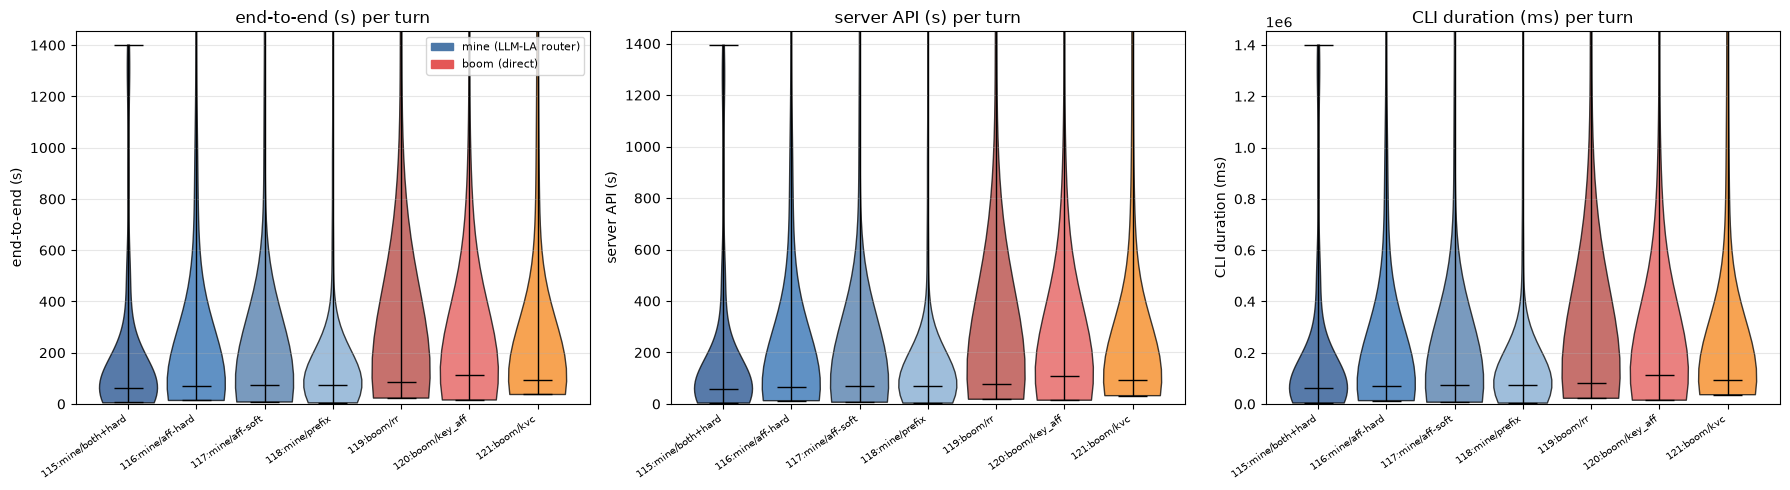

In [6]:
lat_metrics = [("end_to_end_s", "end-to-end (s)"),
               ("api_s", "server API (s)"),
               ("duration_ms", "CLI duration (ms)")]
lat_metrics = [(c, t) for c, t in lat_metrics
               if c in TURNS.columns and TURNS[c].notna().any()]
fig, axes = plt.subplots(1, len(lat_metrics), figsize=(6 * len(lat_metrics), 5))
if len(lat_metrics) == 1:
    axes = [axes]
for ax, (col, ttl) in zip(axes, lat_metrics):
    data = [TURNS[TURNS["exp"] == e][col].dropna().values for e in EXP_IDS]
    parts = ax.violinplot(data, showmedians=True, showextrema=True, widths=0.85)
    for pc, e in zip(parts["bodies"], EXP_IDS):
        pc.set_facecolor(COLORS[e]); pc.set_edgecolor("black"); pc.set_alpha(0.75)
    for key in ("cmedians", "cmaxes", "cmins", "cbars"):
        if key in parts:
            parts[key].set_color("black"); parts[key].set_linewidth(1.0)
    ax.set_xticks(range(1, len(EXP_IDS) + 1))
    ax.set_xticklabels([LABELS[e] for e in EXP_IDS], rotation=35, ha="right", fontsize=7)
    cap = TURNS[col].quantile(.98)
    if pd.notna(cap) and cap > 0:
        ax.set_ylim(0, cap * 1.05)
    ax.set_title(f"{ttl} per turn"); ax.set_ylabel(ttl); ax.grid(axis="y", alpha=.3)
axes[0].legend(handles=[Patch(color="#4C78A8", label="mine (LLM-LA router)"),
                        Patch(color="#E45756", label="boom (direct)")], fontsize=8)
plt.tight_layout(); plt.show()

### 2d. Engine timing: TTFT / TPOT / model latency
Real per-token metrics are captured per router sub-request via streaming, so they
exist **only for the mine cells** (LLM-LA router). BooM runs direct with no router
log, and vLLM's TTFT/TPOT histograms were not scraped into `metrics.jsonl`, so there
is **no TTFT/TPOT for the boom cells** in this dataset. The last table gives an
output-rate proxy (`completion_tokens / api_s`) that *is* computable for both paths,
but note it folds in prefill + tool-loop overhead and is not a true TPOT.

=== TTFT (s) — per router sub-request (mine only) ===


,n,p50,p90,p95,mean
115:mine/both+hard,644.0,1.031,1.450,1.751,1.121
116:mine/aff-hard,700.0,1.055,1.725,1.838,1.176
117:mine/aff-soft,612.0,1.018,1.785,1.950,1.165
118:mine/prefix,563.0,1.046,1.578,1.735,1.138


=== TPOT (s/token) — per router sub-request (mine only) ===


,n,p50,p90,p95,mean
115:mine/both+hard,644.0,0.042,0.049,0.052,0.042
116:mine/aff-hard,700.0,0.044,0.058,0.066,0.046
117:mine/aff-soft,612.0,0.042,0.055,0.063,0.044
118:mine/prefix,563.0,0.042,0.049,0.052,0.042


=== model latency (s) — per router sub-request (mine only) ===


,n,p50,p90,p95,mean
115:mine/both+hard,644.0,13.739,67.699,99.978,27.815
116:mine/aff-hard,700.0,14.448,76.119,116.409,32.454
117:mine/aff-soft,612.0,14.097,66.010,106.991,33.169
118:mine/prefix,563.0,12.493,60.686,83.199,25.594


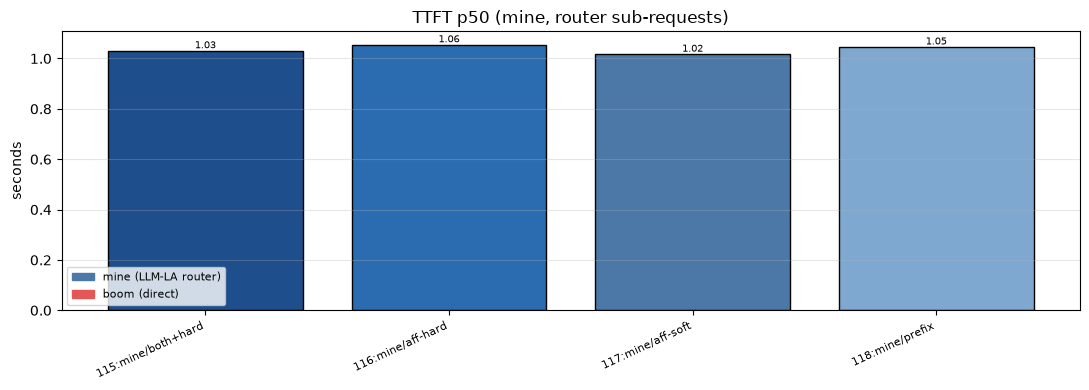

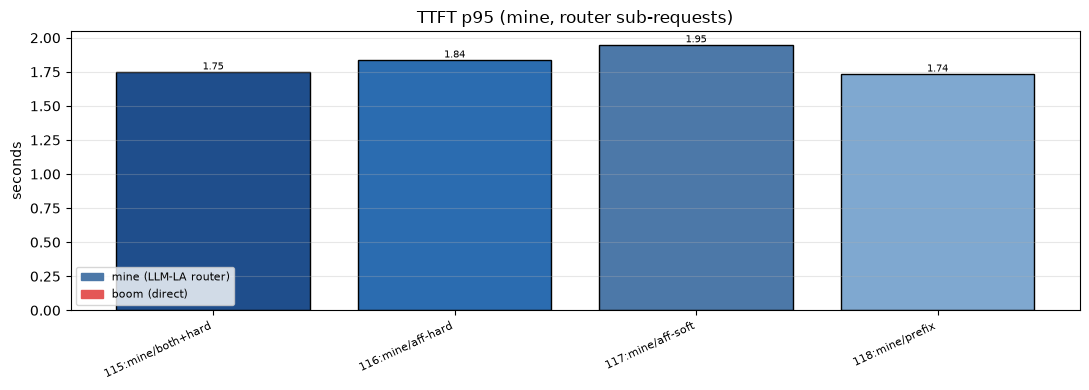

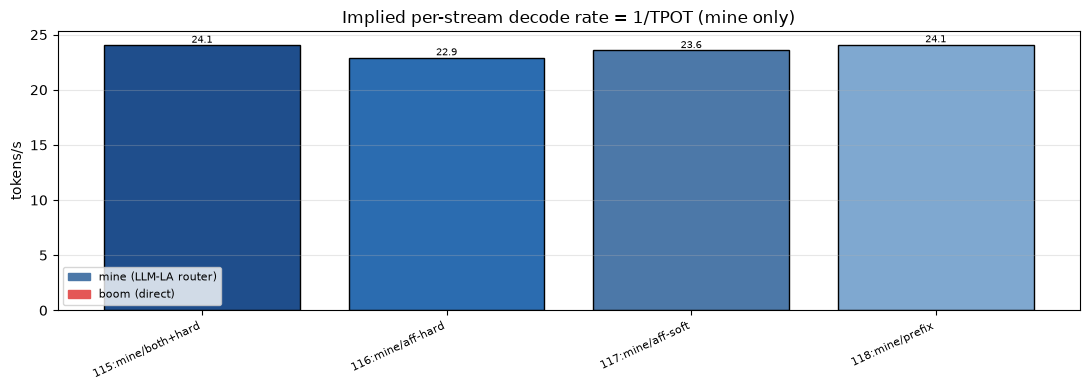

=== output-rate proxy: completion_tokens / api_s (per turn, BOTH paths) ===


,n,mean,p50,p90,p95,p99,max
115:mine/both+hard,110,22.43,22.61,24.55,25.04,28.17,29.05
116:mine/aff-hard,110,21.97,21.94,24.38,25.86,26.84,27.75
117:mine/aff-soft,110,22.08,21.96,24.30,24.52,24.90,25.43
118:mine/prefix,110,22.60,22.60,24.33,24.77,27.53,30.91
119:boom/rr,110,16.24,15.54,19.35,19.69,21.52,22.58
120:boom/key_aff,110,13.39,13.31,16.16,17.13,18.59,19.15
121:boom/kvc,110,15.96,15.01,20.80,22.40,23.76,23.84


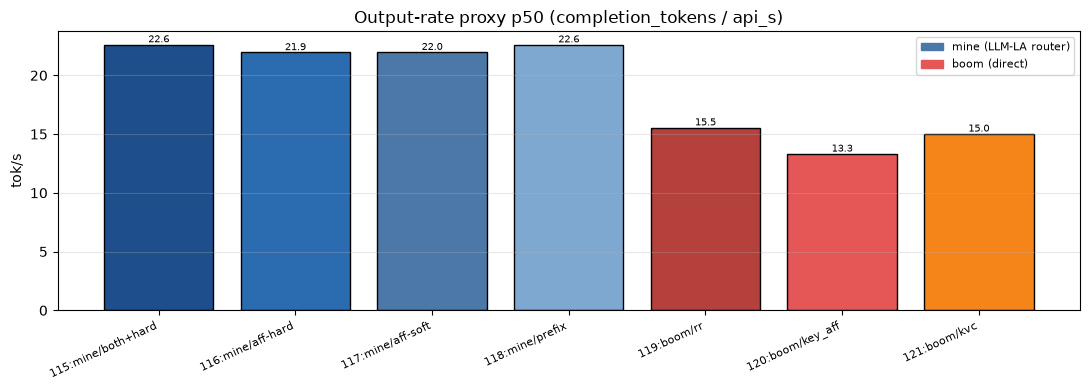

In [7]:
def _pctl(g):
    return pd.Series({"n": len(g), "p50": g.quantile(.50),
                      "p90": g.quantile(.90), "p95": g.quantile(.95),
                      "mean": g.mean()})

eng_rows = {}
for e in EXP_IDS:
    if side(e) != "mine":
        continue
    rl = pd.DataFrame(_read_ndjson(exp_dir(e) / "logs.json"))
    if rl.empty:
        continue
    if "send_failed" in rl.columns:
        rl = rl[rl["send_failed"] != True]
    for c in ["ttft_s", "tpot_avg_s", "model_latency_s"]:
        rl[c] = pd.to_numeric(rl.get(c), errors="coerce")
    eng_rows[e] = rl

for col, ttl in [("ttft_s", "TTFT (s)"), ("tpot_avg_s", "TPOT (s/token)"),
                 ("model_latency_s", "model latency (s)")]:
    tbl = pd.DataFrame({LABELS[e]: _pctl(rl[col].dropna())
                        for e, rl in eng_rows.items()}).T
    print(f"=== {ttl} — per router sub-request (mine only) ===")
    display(tbl.round(3))

# TTFT bars (mine only)
ttft_p50 = {e: eng_rows[e]["ttft_s"].median() for e in eng_rows}
ttft_p95 = {e: eng_rows[e]["ttft_s"].quantile(.95) for e in eng_rows}
bar_by_exp(ttft_p50, "TTFT p50 (mine, router sub-requests)", "seconds", fmt="{:.2f}")
bar_by_exp(ttft_p95, "TTFT p95 (mine, router sub-requests)", "seconds", fmt="{:.2f}")

# decode throughput implied by TPOT (mine only)
tpot_rate = {e: (1.0 / eng_rows[e]["tpot_avg_s"].median())
             for e in eng_rows if eng_rows[e]["tpot_avg_s"].median()}
bar_by_exp(tpot_rate, "Implied per-stream decode rate = 1/TPOT (mine only)",
           "tokens/s", fmt="{:.1f}")

# output-rate proxy computable for BOTH paths (turn-level)
TURNS["out_tok_per_s"] = TURNS["completion_tokens"] / TURNS["api_s"].replace(0, np.nan)
proxy = pctl_table(TURNS[TURNS["out_tok_per_s"].replace([np.inf, -np.inf], np.nan).notna()],
                   "out_tok_per_s")
print("=== output-rate proxy: completion_tokens / api_s (per turn, BOTH paths) ===")
display(proxy.round(2))
bar_by_exp({e: TURNS[TURNS["exp"] == e]["out_tok_per_s"]
            .replace([np.inf, -np.inf], np.nan).median() for e in EXP_IDS},
           "Output-rate proxy p50 (completion_tokens / api_s)", "tok/s", fmt="{:.1f}")

### 2e. Engine-side TTFT / e2e / throughput / prefix-cache (backfilled from Prometheus)
The live client scraper only stored per-pod gauges, but the central Prometheus
(`http://192.168.0.79:31190`) **retains the vLLM histogram counters**, so we backfill
true engine metrics for **all 7 cells (boom included)** over each cell's exact
`metrics.jsonl` window using `increase(...)` / `histogram_quantile(...)`.
Cached to `prom_engine_backfill.json`; regenerate against live Prometheus if missing.

**Headline:** engine-reported prefix-cache hit rate is **~80–93% for mine** vs **0% for
every boom cell** (including `kvc_aware`), which directly explains boom's 3–7x worse TTFT.
`time_per_output_token_seconds` is not exported by this vLLM build, so TPOT is derived
as `(e2e_avg - ttft_avg) / gen_tokens_per_req`.

loaded cached backfill: prom_engine_backfill.json


,reqs,ttft_p50,ttft_p95,ttft_avg,e2e_p50,e2e_p95,e2e_avg,tpot_derived_s,decode_tok_s,prefix_hit_rate
115:mine/both+hard,643.502,0.706,1.730,0.794,13.304,107.820,27.540,0.043,102.767,0.918
116:mine/aff-hard,699.820,0.731,2.038,0.813,14.141,117.317,32.133,0.047,52.159,0.935
117:mine/aff-soft,611.768,0.764,2.179,0.859,13.605,116.523,32.934,0.046,73.783,0.830
118:mine/prefix,562.543,0.780,2.023,0.837,12.308,99.000,25.320,0.042,98.288,0.799
119:boom/rr,751.505,2.344,15.623,3.893,20.840,118.807,37.783,0.056,45.012,0.000
120:boom/key_aff,602.151,2.685,11.932,3.494,19.366,156.692,44.965,0.066,50.972,0.000
121:boom/kvc,634.804,2.437,14.807,3.705,21.799,119.401,40.462,0.057,52.184,0.000


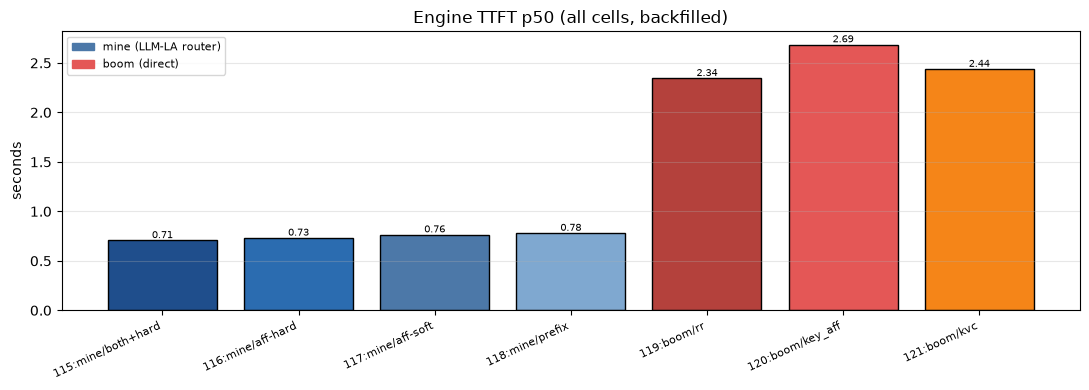

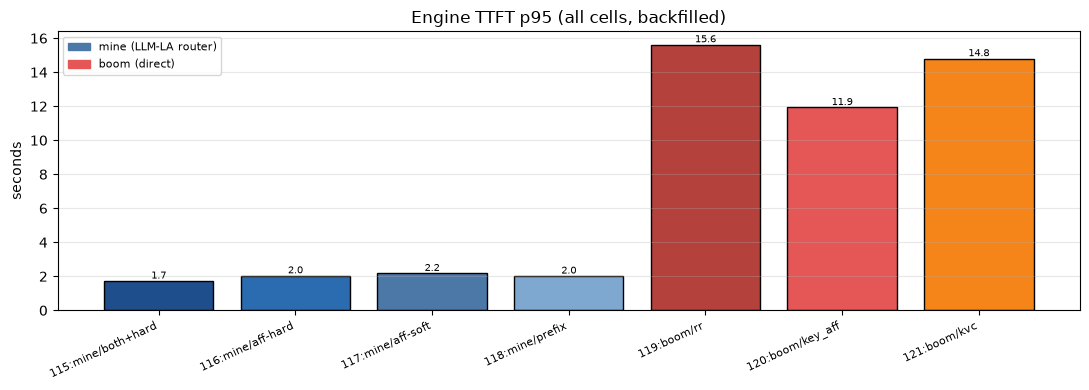

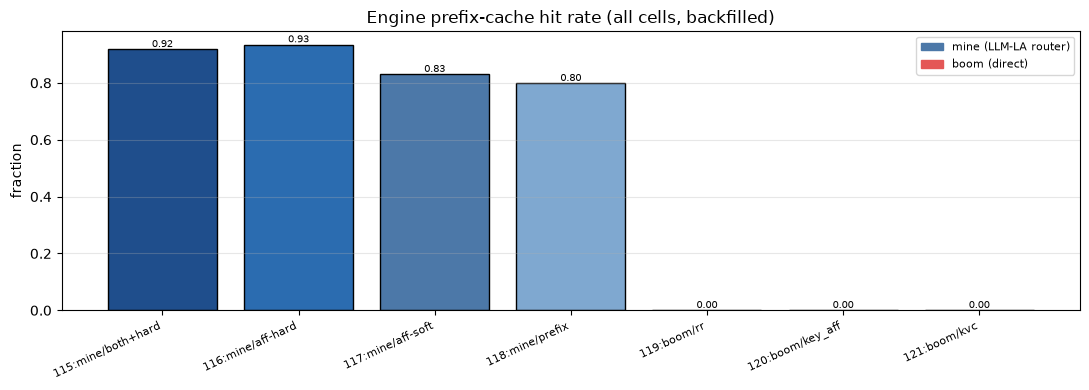

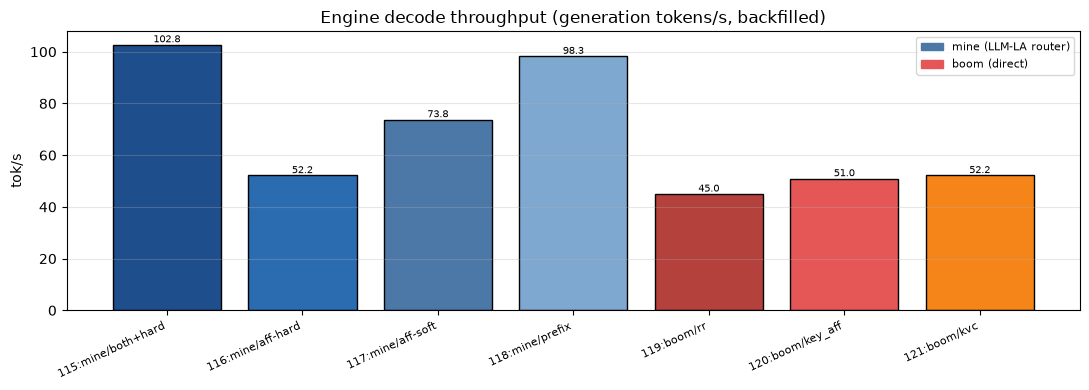

In [8]:
BACKFILL_PATH = Path(EXPERIMENTS_ROOT) / "prom_engine_backfill.json"
PROM_BASE = "http://192.168.0.79:31190"

def _iso2unix(s):
    from datetime import datetime
    return datetime.fromisoformat(s).timestamp()

def _win(e):
    ts = [r.get("ts") for r in _read_ndjson(exp_dir(e) / "metrics.jsonl") if r.get("ts")]
    return _iso2unix(ts[0]), _iso2unix(ts[-1])

def backfill_live():
    """Query Prometheus directly (fallback when the cache file is absent)."""
    import requests
    def q(expr, t):
        r = requests.get(f"{PROM_BASE}/api/v1/query",
                         params={"query": expr, "time": t}, timeout=25)
        res = r.json().get("data", {}).get("result", [])
        if not res:
            return None
        v = res[0]["value"][1]
        return None if v in ("NaN", None) else float(v)
    V = "vllm:"; out = {}
    for e in EXP_IDS:
        s, en = _win(e); d = int(en - s)
        a = lambda expr: q(expr, en)
        tsum = a(f"sum(increase({V}time_to_first_token_seconds_sum[{d}s]))")
        tcnt = a(f"sum(increase({V}time_to_first_token_seconds_count[{d}s]))")
        esum = a(f"sum(increase({V}e2e_request_latency_seconds_sum[{d}s]))")
        ecnt = a(f"sum(increase({V}e2e_request_latency_seconds_count[{d}s]))")
        gen = a(f"sum(increase({V}generation_tokens_total[{d}s]))")
        hits = a(f"sum(increase({V}prefix_cache_hits_total[{d}s]))")
        qrs = a(f"sum(increase({V}prefix_cache_queries_total[{d}s]))")
        rec = {"label": LABELS[e], "dur_s": d, "reqs": ecnt,
               "ttft_avg": (tsum / tcnt) if tsum and tcnt else None,
               "ttft_p50": a(f"histogram_quantile(0.50, sum by (le)(increase({V}time_to_first_token_seconds_bucket[{d}s])))"),
               "ttft_p95": a(f"histogram_quantile(0.95, sum by (le)(increase({V}time_to_first_token_seconds_bucket[{d}s])))"),
               "e2e_avg": (esum / ecnt) if esum and ecnt else None,
               "e2e_p50": a(f"histogram_quantile(0.50, sum by (le)(increase({V}e2e_request_latency_seconds_bucket[{d}s])))"),
               "e2e_p95": a(f"histogram_quantile(0.95, sum by (le)(increase({V}e2e_request_latency_seconds_bucket[{d}s])))"),
               "gen_tokens": gen, "decode_tok_s": (gen / d) if gen else None,
               "prefix_hit_rate": (hits / qrs) if (qrs and qrs > 0) else None}
        if rec["e2e_avg"] and rec["ttft_avg"] and gen and ecnt:
            rec["tpot_derived_s"] = (rec["e2e_avg"] - rec["ttft_avg"]) / (gen / ecnt)
        out[str(e)] = rec
    return out

if BACKFILL_PATH.is_file():
    BF = json.load(BACKFILL_PATH.open())
    print("loaded cached backfill:", BACKFILL_PATH.name)
else:
    print("cache missing -> querying Prometheus live ...")
    BF = backfill_live()
    json.dump(BF, BACKFILL_PATH.open("w"), indent=2)

ENG = pd.DataFrame({LABELS[e]: BF.get(str(e), {}) for e in EXP_IDS}).T
cols = ["reqs", "ttft_p50", "ttft_p95", "ttft_avg", "e2e_p50", "e2e_p95",
        "e2e_avg", "tpot_derived_s", "decode_tok_s", "prefix_hit_rate"]
cols = [c for c in cols if c in ENG.columns]
display(ENG[cols].astype(float).round(3))

bar_by_exp({e: float(BF[str(e)]["ttft_p50"]) for e in EXP_IDS if BF.get(str(e), {}).get("ttft_p50") is not None},
           "Engine TTFT p50 (all cells, backfilled)", "seconds", fmt="{:.2f}")
bar_by_exp({e: float(BF[str(e)]["ttft_p95"]) for e in EXP_IDS if BF.get(str(e), {}).get("ttft_p95") is not None},
           "Engine TTFT p95 (all cells, backfilled)", "seconds", fmt="{:.1f}")
bar_by_exp({e: float(BF[str(e)]["prefix_hit_rate"]) for e in EXP_IDS if BF.get(str(e), {}).get("prefix_hit_rate") is not None},
           "Engine prefix-cache hit rate (all cells, backfilled)", "fraction", fmt="{:.2f}")
bar_by_exp({e: float(BF[str(e)]["decode_tok_s"]) for e in EXP_IDS if BF.get(str(e), {}).get("decode_tok_s") is not None},
           "Engine decode throughput (generation tokens/s, backfilled)", "tok/s", fmt="{:.1f}")

## 3. Makespan & throughput
Same 110-turn workload under the same closed-loop concurrency, so total makespan
(`load_runner_duration_s`) measures how fast each strategy cleared the work.
Throughput is derived from the per-turn logs (path-agnostic), normalized by makespan.

,makespan_min,turns,turns_per_min,decode_tok_s,prompt_tok_s
label,,,,,
115:mine/both+hard,65.1,110,1.69,102.7,6083.0
116:mine/aff-hard,148.0,110,0.74,52.1,3356.7
117:mine/aff-soft,96.8,110,1.14,73.7,4139.8
118:mine/prefix,55.1,110,2.00,98.2,5577.8
119:boom/rr,168.9,110,0.65,45.0,3144.9
120:boom/key_aff,124.2,110,0.89,50.9,3078.3
121:boom/kvc,129.8,110,0.85,52.1,3257.5


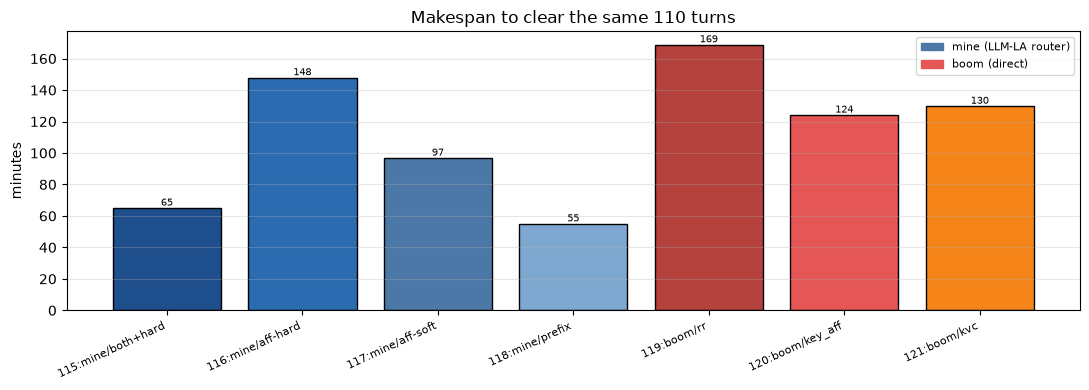

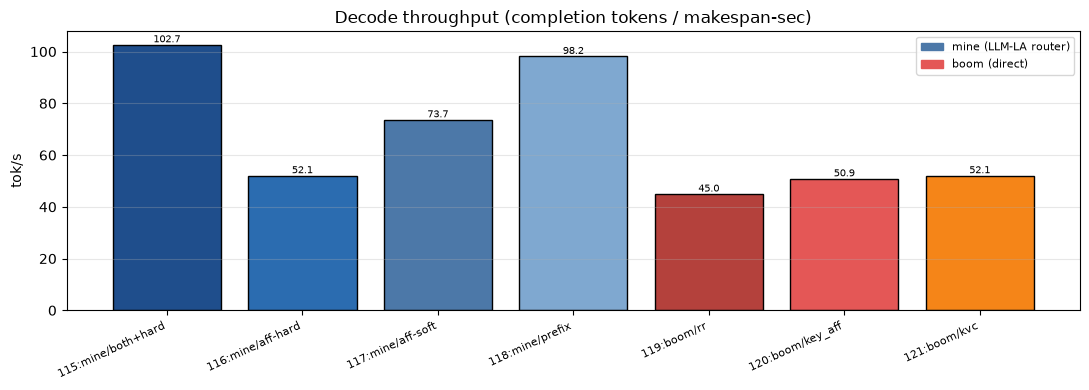

In [9]:
rows = []
for e in EXP_IDS:
    d = TURNS[TURNS["exp"] == e]
    load_s = REG.loc[e, "load_s"] or np.nan
    comp = d["completion_tokens"].sum()
    prompt = d["prompt_tokens"].sum()
    rows.append({
        "label": LABELS[e], "exp": e,
        "makespan_min": round(load_s / 60, 1) if pd.notna(load_s) else np.nan,
        "turns": len(d),
        "turns_per_min": round(len(d) / (load_s / 60), 2) if pd.notna(load_s) else np.nan,
        "decode_tok_s": round(comp / load_s, 1) if pd.notna(load_s) else np.nan,
        "prompt_tok_s": round(prompt / load_s, 1) if pd.notna(load_s) else np.nan,
        "sum_completion_tok": int(comp), "sum_prompt_tok": int(prompt),
    })
THRU = pd.DataFrame(rows).set_index("label")
display(THRU[["makespan_min", "turns", "turns_per_min", "decode_tok_s",
              "prompt_tok_s"]])

bar_by_exp({e: REG.loc[e, "load_s"] / 60 for e in EXP_IDS},
           "Makespan to clear the same 110 turns", "minutes", fmt="{:.0f}")
bar_by_exp({r["exp"]: r["decode_tok_s"] for r in rows},
           "Decode throughput (completion tokens / makespan-sec)", "tok/s", fmt="{:.1f}")

## 4. Token profile
Sanity check on request size: prompt and completion tokens per turn.

,prompt_p50,prompt_p95,prompt_max,comp_p50,comp_p95,comp_max
115:mine/both+hard,114646.0,874761.0,1795907,1286.0,19186.0,31678
116:mine/aff-hard,103336.0,873579.0,5689189,1412.0,19933.0,82796
117:mine/aff-soft,105465.0,376662.0,5712177,1462.0,7346.0,99941
118:mine/prefix,102369.0,389718.0,2625887,1562.0,6181.0,62791
119:boom/rr,130467.0,788253.0,8004356,1244.0,11405.0,112809
120:boom/key_aff,101350.0,562762.0,4555943,1436.0,9828.0,94308
121:boom/kvc,123196.0,740614.0,4905430,1508.0,13594.0,87523


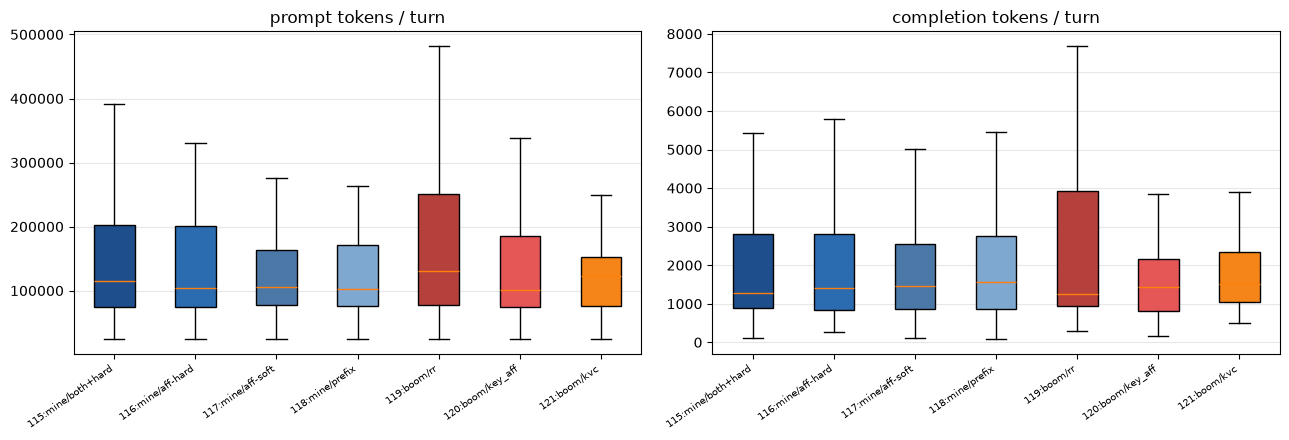

In [10]:
tok = TURNS.groupby("exp").agg(
    prompt_p50=("prompt_tokens", lambda s: s.quantile(.50)),
    prompt_p95=("prompt_tokens", lambda s: s.quantile(.95)),
    prompt_max=("prompt_tokens", "max"),
    comp_p50=("completion_tokens", lambda s: s.quantile(.50)),
    comp_p95=("completion_tokens", lambda s: s.quantile(.95)),
    comp_max=("completion_tokens", "max"),
)
tok.index = [LABELS[e] for e in tok.index]
display(tok.round(0))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, col, ttl in [(axes[0], "prompt_tokens", "prompt tokens / turn"),
                     (axes[1], "completion_tokens", "completion tokens / turn")]:
    data = [TURNS[TURNS["exp"] == e][col].dropna().values for e in EXP_IDS]
    bp = ax.boxplot(data, showfliers=False, patch_artist=True)
    for patch, e in zip(bp["boxes"], EXP_IDS):
        patch.set_facecolor(COLORS[e])
    ax.set_xticks(range(1, len(EXP_IDS) + 1))
    ax.set_xticklabels([LABELS[e] for e in EXP_IDS], rotation=35, ha="right", fontsize=7)
    ax.set_title(ttl)
    ax.grid(axis="y", alpha=.3)
plt.tight_layout(); plt.show()

## 5. Router-level KV reuse (mine only)
BooM runs in **direct** mode with no router log, so `kv_hit` / `matched_tokens`
exist only for the LLM-LA cells. This is the per-router-request prefix-cache hit
seen by our router (644–700 sub-requests per cell).

,router_reqs,kv_hit_frac,matched_tok_p50,matched_frac_of_prompt
label,,,,
115:mine/both+hard,644,0.4224,0.0,0.0
116:mine/aff-hard,700,0.4729,0.0,0.0
117:mine/aff-soft,612,0.4428,0.0,0.0
118:mine/prefix,563,0.4885,0.0,0.0


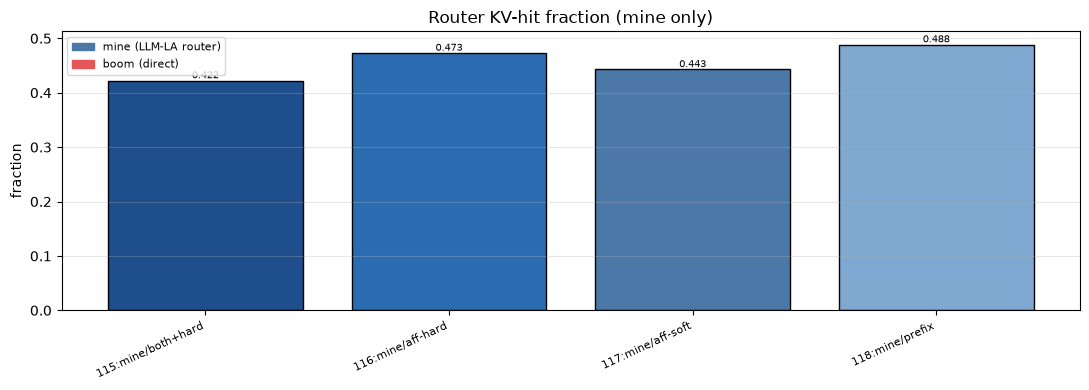

In [11]:
kv_rows = []
for e in EXP_IDS:
    if side(e) != "mine":
        continue
    rl = pd.DataFrame(_read_ndjson(exp_dir(e) / "logs.json"))
    if rl.empty or "kv_hit" not in rl.columns:
        continue
    rl = rl[rl.get("send_failed", False) != True] if "send_failed" in rl.columns else rl
    kh = rl["kv_hit"].dropna().astype(bool)
    mt = pd.to_numeric(rl.get("matched_tokens"), errors="coerce")
    pt = pd.to_numeric(rl.get("prompt_tokens"), errors="coerce")
    kv_rows.append({
        "label": LABELS[e], "router_reqs": len(rl),
        "kv_hit_frac": round(kh.mean(), 4) if len(kh) else np.nan,
        "matched_tok_p50": round(mt.median(), 0) if mt.notna().any() else np.nan,
        "matched_frac_of_prompt": round((mt / pt).replace([np.inf, -np.inf], np.nan).median(), 4)
            if mt.notna().any() and pt.notna().any() else np.nan,
    })
KVR = pd.DataFrame(kv_rows).set_index("label")
display(KVR)
if not KVR.empty:
    vals = {int(l.split(":")[0]): KVR.loc[l, "kv_hit_frac"] for l in KVR.index}
    bar_by_exp(vals, "Router KV-hit fraction (mine only)", "fraction", fmt="{:.3f}")

## 6. vLLM fleet metrics (`metrics.jsonl`)
Recomputed per-pod (engine `prefix_cache_hit_rate` came back empty, so we use
`kv_cache_usage_perc` and `requests_running` — the reliable engine signals).

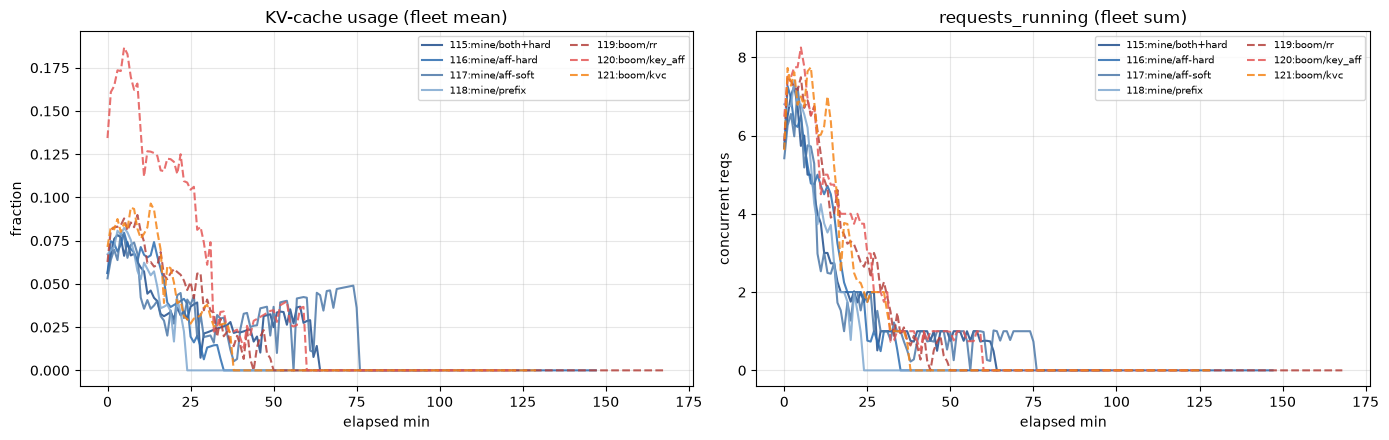

In [12]:
def load_ts(e):
    out = []
    for r in _read_ndjson(exp_dir(e) / "metrics.jsonl"):
        ts = r.get("ts")
        for s in (r.get("samples") or []):
            if s.get("kv_cache_usage_perc") is None and s.get("requests_running") is None:
                continue
            out.append({"ts": ts, "pod": s.get("pod") or s.get("instance"),
                        "kv_cache_usage_perc": s.get("kv_cache_usage_perc"),
                        "requests_running": s.get("requests_running"),
                        "requests_waiting": s.get("requests_waiting")})
    df = pd.DataFrame(out)
    if df.empty:
        return df
    df["ts"] = pd.to_datetime(df["ts"], errors="coerce", utc=True)
    df = df.dropna(subset=["ts"])
    df["t_min"] = (df["ts"] - df["ts"].min()).dt.total_seconds() / 60
    return df

TS = {e: load_ts(e) for e in EXP_IDS}

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for e in EXP_IDS:
    d = TS[e]
    if d.empty:
        continue
    # fleet = sum across pods per tick, then rolling-mean over 1-min bins
    for ax, col, agg in [(axes[0], "kv_cache_usage_perc", "mean"),
                         (axes[1], "requests_running", "sum")]:
        g = d.groupby("ts")[col]
        fleet = g.mean() if agg == "mean" else g.sum()
        tt = d.groupby("ts")["t_min"].first()
        s = pd.DataFrame({"t": tt, "v": fleet}).dropna()
        s["bin"] = (s["t"] // 1).astype(int)
        b = s.groupby("bin")["v"].mean()
        ax.plot(b.index, b.values, color=COLORS[e], label=LABELS[e],
                ls="--" if side(e) == "boom" else "-", alpha=.85)
axes[0].set_title("KV-cache usage (fleet mean)"); axes[0].set_ylabel("fraction")
axes[1].set_title("requests_running (fleet sum)"); axes[1].set_ylabel("concurrent reqs")
for ax in axes:
    ax.set_xlabel("elapsed min"); ax.grid(alpha=.3); ax.legend(fontsize=7, ncol=2)
plt.tight_layout(); plt.show()

## 7. Load balance across pods
How evenly each strategy spread work over the two vLLM leader pods.
For *mine* we use `endpoint_tokens.json` (real endpoints); for all cells we also
use time-averaged `requests_running` per pod from `metrics.jsonl`.
Jain fairness index: 1.0 = perfectly balanced, 0.5 = all on one of two pods.

,pods_active,jain_running,jain_tokens,pod_running_share
label,,,,
115:mine/both+hard,2,0.984,0.958,"{'vllm-minimax-m2-0': 1.17, 'vllm-minimax-m2-1..."
116:mine/aff-hard,2,0.999,0.932,"{'vllm-minimax-m2-0': 0.37, 'vllm-minimax-m2-1..."
117:mine/aff-soft,2,0.992,0.971,"{'vllm-minimax-m2-0': 0.77, 'vllm-minimax-m2-1..."
118:mine/prefix,2,0.999,0.999,"{'vllm-minimax-m2-0': 0.86, 'vllm-minimax-m2-1..."
119:boom/rr,2,0.992,NaN,"{'vllm-minimax-m2-0': 0.43, 'vllm-minimax-m2-1..."
120:boom/key_aff,1,1.000,NaN,{'vllm-minimax-m2-0': 1.45}
121:boom/kvc,2,0.766,NaN,"{'vllm-minimax-m2-0': 0.92, 'vllm-minimax-m2-1..."


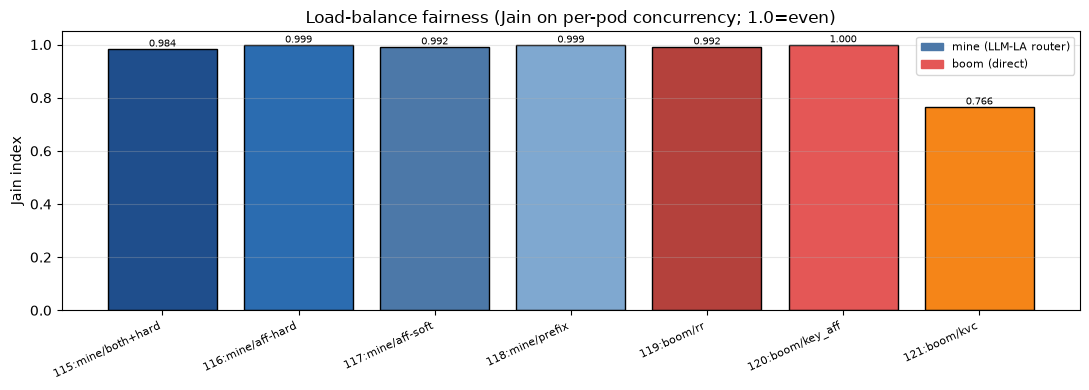

In [13]:
def jain(x):
    x = np.asarray([v for v in x if v is not None and not np.isnan(v)], dtype=float)
    if x.size == 0 or x.sum() == 0:
        return np.nan
    return (x.sum() ** 2) / (x.size * (x ** 2).sum())

lb_rows = []
for e in EXP_IDS:
    # per-pod avg concurrency from metrics
    d = TS[e]
    per_pod = d.groupby("pod")["requests_running"].mean() if not d.empty else pd.Series(dtype=float)
    pods_seen = int((per_pod > 0).sum()) if not per_pod.empty else 0
    # per-endpoint tokens (mine has real endpoints; boom often _unknown_)
    et = _read_json(exp_dir(e) / "endpoint_tokens.json") or {}
    pe = {p["endpoint"]: p["total_tokens"] for p in et.get("per_endpoint", [])}
    real_ep = {k: v for k, v in pe.items() if k != "_unknown_"}
    lb_rows.append({
        "label": LABELS[e],
        "pods_active": pods_seen,
        "jain_running": round(jain(per_pod.values), 3) if not per_pod.empty else np.nan,
        "jain_tokens": round(jain(list(real_ep.values())), 3) if real_ep else np.nan,
        "pod_running_share": {k: round(v, 2) for k, v in per_pod.round(2).to_dict().items()},
    })
LB = pd.DataFrame(lb_rows).set_index("label")
display(LB)

vals = {int(l.split(":")[0]): LB.loc[l, "jain_running"] for l in LB.index
        if pd.notna(LB.loc[l, "jain_running"])}
bar_by_exp(vals, "Load-balance fairness (Jain on per-pod concurrency; 1.0=even)",
           "Jain index", fmt="{:.3f}")

## 8. Head-to-head summary
Lower latency/makespan is better; higher throughput/kv_hit/fairness is better.

In [14]:
S = pd.DataFrame(index=[LABELS[e] for e in EXP_IDS])
S["side"] = [side(e) for e in EXP_IDS]
S["makespan_min"] = [round((REG.loc[e, "load_s"] or np.nan) / 60, 1) for e in EXP_IDS]
g50 = TURNS.groupby("exp")["end_to_end_s"].quantile(.50)
g95 = TURNS.groupby("exp")["end_to_end_s"].quantile(.95)
gmean = TURNS.groupby("exp")["end_to_end_s"].mean()
S["e2e_p50_s"] = [round(g50.get(e, np.nan), 1) for e in EXP_IDS]
S["e2e_p95_s"] = [round(g95.get(e, np.nan), 1) for e in EXP_IDS]
S["e2e_mean_s"] = [round(gmean.get(e, np.nan), 1) for e in EXP_IDS]
S["decode_tok_s"] = [THRU.loc[LABELS[e], "decode_tok_s"] for e in EXP_IDS]
S["kv_hit"] = [KVR.loc[LABELS[e], "kv_hit_frac"] if LABELS[e] in KVR.index else np.nan
               for e in EXP_IDS]
S["pods_active"] = [LB.loc[LABELS[e], "pods_active"] for e in EXP_IDS]
S["jain_running"] = [LB.loc[LABELS[e], "jain_running"] for e in EXP_IDS]

def _bf(e, k):
    v = BF.get(str(e), {}).get(k)
    return float(v) if v is not None else np.nan
S["eng_ttft_p50"] = [_bf(e, "ttft_p50") for e in EXP_IDS]
S["eng_ttft_p95"] = [_bf(e, "ttft_p95") for e in EXP_IDS]
S["eng_ttft_mean"] = [_bf(e, "ttft_avg") for e in EXP_IDS]
S["eng_e2e_mean"] = [_bf(e, "e2e_avg") for e in EXP_IDS]
S["eng_prefix_hit"] = [_bf(e, "prefix_hit_rate") for e in EXP_IDS]

def _fmt(col, best):
    v = S[col]
    win = v.min() if best == "min" else v.max()
    return [f"{x}{' *' if x == win else ''}" if pd.notna(x) else "" for x in v]

show = S.copy()
print("Head-to-head (* = best in column)")
display(S.round(3))

# highlight mine-vs-boom bests
best_lat = S["e2e_p50_s"].idxmin()
best_make = S["makespan_min"].idxmin()
best_thru = S["decode_tok_s"].idxmax()
best_ttft = S["eng_ttft_p50"].idxmin()
best_pfx = S["eng_prefix_hit"].idxmax()
print(f"\nBest p50 latency  : {best_lat}  ({S.loc[best_lat,'e2e_p50_s']} s)")
print(f"Best makespan     : {best_make} ({S.loc[best_make,'makespan_min']} min)")
print(f"Best throughput   : {best_thru} ({S.loc[best_thru,'decode_tok_s']} tok/s)")
print(f"Best engine TTFT  : {best_ttft} ({S.loc[best_ttft,'eng_ttft_p50']:.2f} s p50)")
print(f"Best prefix-hit   : {best_pfx} ({S.loc[best_pfx,'eng_prefix_hit']:.2f})")

Head-to-head (* = best in column)


,side,makespan_min,e2e_p50_s,e2e_p95_s,e2e_mean_s,decode_tok_s,kv_hit,pods_active,jain_running,eng_ttft_p50,eng_ttft_p95,eng_ttft_mean,eng_e2e_mean,eng_prefix_hit
115:mine/both+hard,mine,65.1,62.0,852.6,168.2,102.7,0.422,2,0.984,0.706,1.730,0.794,27.540,0.918
116:mine/aff-hard,mine,148.0,69.2,882.7,212.6,52.1,0.473,2,0.999,0.731,2.038,0.813,32.133,0.935
117:mine/aff-soft,mine,96.8,73.8,326.4,189.8,73.7,0.443,2,0.992,0.764,2.179,0.859,32.934,0.830
118:mine/prefix,mine,55.1,74.1,268.6,135.8,98.2,0.488,2,0.999,0.780,2.023,0.837,25.320,0.799
119:boom/rr,boom,168.9,84.3,647.9,263.3,45.0,NaN,2,0.992,2.344,15.623,3.893,37.783,0.000
120:boom/key_aff,boom,124.2,114.6,704.2,250.3,50.9,NaN,1,1.000,2.685,11.932,3.494,44.965,0.000
121:boom/kvc,boom,129.8,94.6,990.3,242.2,52.1,NaN,2,0.766,2.437,14.807,3.705,40.462,0.000



Best p50 latency  : 115:mine/both+hard  (62.0 s)
Best makespan     : 118:mine/prefix (55.1 min)
Best throughput   : 115:mine/both+hard (102.7 tok/s)
Best engine TTFT  : 115:mine/both+hard (0.71 s p50)
Best prefix-hit   : 116:mine/aff-hard (0.93)


### What to look for
- **Latency (§2)** and **makespan (§3)** are the fairest cross-path comparisons — identical 110-turn workload.
- **mine vs boom:** compare the blue (LLM-LA router) cells against the warm (BooM direct) cells on p50/p95 latency and makespan.
- **§7 load balance:** `boom/key_aff` (exp 120) collapsed traffic onto a **single pod** (`pods_active=1`, `jain≈0.5`) — expect its concurrency and tail latency to suffer.
- **Engine backfill (§2e) is the decisive apples-to-apples result:** true vLLM TTFT / e2e / throughput / prefix-cache-hit for **all 7 cells including boom**, pulled from Prometheus histogram retention. Engine prefix-cache hit is **~80–93% for mine vs 0% for every boom cell** (even `kvc_aware`), and mine's TTFT p50 is ~3.4x lower / p95 ~7x lower.
- **KV reuse:** §5 is the mine-only router view; §2e is the engine ground-truth available for both paths.
- **Caveats:** the shared cluster means makespan carries external variance; live `cache_read`, live `prefix_cache_hit_rate` fields, and `metrics_summary.json` were unreliable and are replaced by the §2e Prometheus backfill. `time_per_output_token_seconds` isn't exported (TPOT is derived).